## MS/MS Fragmentation & Fragment Matching

MRM-HR 데이터에서 각 화합물의 **MS/MS 스펙트럼**을 추출하고,
엑셀에 정의된 **Q3 (product ion)**이 실제로 존재하는지 매칭하여 **동정(identification)**을 확인합니다.

### 환경 설정

이 셀은 노트북 실행에 필요한 라이브러리를 설치하고 import합니다. 이전 노트북(01~03)을 이미 실행했다면 건너뛰어도 됩니다.

- **pyopenms**: mzML 파일 파싱 및 mass spectrometry 데이터 처리
- **scipy**: 신호 처리 (smoothing, peak detection) 및 수치 적분
- **matplotlib**: 스펙트럼 시각화

In [1]:
!pip install -q pyopenms scipy matplotlib numpy pandas openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from scipy import integrate
import pyopenms as oms
import openpyxl, os, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

### 데이터 로드 및 XIC 추출

이전 노트북에서 사용한 mzML 파일과 엑셀 화합물 목록을 다시 로드합니다. 독립 실행 시 필요한 모든 데이터를 이 셀에서 준비합니다.

- **mzML 파일**: TOFMS 원본 데이터 (MS1 full scan)
- **엑셀 파일**: 표준물질 목록 (이름, 분자량, adduct 정보)
- **XIC 추출**: 각 화합물의 m/z에서 extracted ion chromatogram 생성

In [2]:
# === 데이터 로드 ===
DATA_DIR = 'echo-tof-colab/data'
MZML_DIR = f'{DATA_DIR}/mzml'
TOFMS_FILE = f'{MZML_DIR}/20260330_TOFMS.mzML'
MRMHR_FILE = f'{MZML_DIR}/20260330_MRMHR_Q1Q3_Final.mzML'
EXCEL_FILE = f'{DATA_DIR}/Explosives_EchoMS_20260331.xlsx'

def load_mzml(filepath):
    """mzML 파일을 로드하여 MSExperiment 객체 반환"""
    exp = oms.MSExperiment()
    oms.MzMLFile().load(filepath, exp)
    print(f'로드 완료: {os.path.basename(filepath)} ({exp.getNrSpectra()} spectra)')
    return exp

exp_tof = load_mzml(TOFMS_FILE)

def extract_tic(exp, ms_level=1):
    """TIC 추출"""
    rt_list, tic_list = [], []
    for spec in exp:
        if spec.getMSLevel() == ms_level:
            rt_list.append(spec.getRT() / 60.0)
            mz, intensity = spec.get_peaks()
            tic_list.append(np.sum(intensity))
    return np.array(rt_list), np.array(tic_list)

rt_tof, tic_tof = extract_tic(exp_tof)

def extract_xic(exp, target_mz, tolerance_ppm=20.0, ms_level=1):
    """XIC 추출: target_mz ± tolerance 범위의 intensity 합"""
    rt_list, int_list = [], []
    tol = target_mz * tolerance_ppm * 1e-6
    for spec in exp:
        if spec.getMSLevel() == ms_level:
            rt_list.append(spec.getRT() / 60.0)
            mz, ints = spec.get_peaks()
            mask = (mz >= target_mz - tol) & (mz <= target_mz + tol)
            int_list.append(float(ints[mask].sum()) if mask.any() else 0.0)
    return np.array(rt_list), np.array(int_list)

# 화합물 스킴 로드
wb = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
ws_std = wb['STD list']
compounds = []
for row in ws_std.iter_rows(min_row=2, max_row=16, values_only=True):
    if row[0] and row[1]:
        compounds.append({'name': str(row[2] or row[1]), 'full_name': str(row[1]), 'mz': None})

# XIC 추출
target_compounds = {
    'TNT': {'mz': 226.009, 'adduct': '[M-H]-'},
    'RDX': {'mz': 281.048, 'adduct': '[M+CH3COO]-'},
    'HMX': {'mz': 355.0592, 'adduct': '[M+CH3COO]-'},
    '2,4-DNT': {'mz': 181.0124, 'adduct': '[M-H]-'},
    'Tetryl': {'mz': 241.0204, 'adduct': '[M-NO2]-'},
    '4-Am-DNT': {'mz': 196.0358, 'adduct': '[M-H]-'},
    '2,6-DNT': {'mz': 182.018, 'adduct': '[M]-'},
}

xic_data = {}
for name, info in target_compounds.items():
    rt, intensity = extract_xic(exp_tof, info['mz'])
    xic_data[name] = {'rt': rt, 'intensity': intensity, 'mz': info['mz']}

detected = {k: v for k, v in xic_data.items() if v['intensity'].max() > 0}
print(f'검출된 화합물: {len(detected)}/{len(target_compounds)}')

Loaded: 20260330_TOFMS.mzML (495 spectra)
Detected compounds: 7/7



---

### MS/MS란 무엇인가?

**MS/MS (Tandem Mass Spectrometry)**는 두 단계의 질량 분석을 수행하는 기법입니다.

1. **Q1 (Precursor Ion Selection)**: 첫 번째 질량 분석기에서 특정 m/z의 이온(precursor ion)만 선택합니다
2. **Collision Cell**: 선택된 이온을 충돌시켜 조각(fragment)으로 분해합니다
3. **Q3 (Product Ion Detection)**: 두 번째 질량 분석기에서 생성된 fragment ion들을 검출합니다

이 과정을 통해 단순히 분자량만으로는 구별할 수 없는 화합물을 **고유한 fragmentation pattern**으로 확인할 수 있습니다. MS/MS는 compound identification의 gold standard입니다.

### MRM-HR 데이터 로드

**MRM-HR (Multiple Reaction Monitoring - High Resolution)**은 특정 precursor ion에 대해 targeted MS/MS를 수행하는 모드입니다. 일반 MS/MS와 달리, 미리 정의된 precursor m/z 목록에 대해서만 fragmentation을 수행하므로 감도와 선택성이 높습니다.

- Q1에서 precursor ion을 선택하고, Q3에서 product ion을 고해상도로 측정합니다
- 엑셀 파일의 Q1/Q3 transition 목록이 이 실험의 "레시피"입니다

In [3]:
# MRM-HR 데이터 로드
exp_mrm = load_mzml(MRMHR_FILE)

Loaded: 20260330_MRMHR_Q1Q3_Final.mzML (3176 spectra)



### MS/MS 스펙트럼 추출 함수

각 화합물의 precursor m/z에 해당하는 MS/MS 스펙트럼을 mzML 파일에서 추출합니다. MRM-HR 데이터에서는 각 스캔이 특정 precursor ion의 fragmentation 결과를 담고 있습니다.

- **precursor_mz**: Q1에서 선택한 모이온의 m/z
- **tolerance_ppm**: precursor m/z 매칭 허용 오차 (ppm 단위)
- 동일 precursor에 대한 여러 스캔의 스펙트럼을 **평균**하여 노이즈를 줄입니다

In [4]:
def extract_msms_spectrum(exp, precursor_mz, tolerance_ppm=50.0):
    """특정 precursor m/z에 해당하는 MS/MS 스펙트럼 수집 및 평균화
    
    MRM-HR에서는 동일 precursor에 대한 여러 스캔이 있으므로
    intensity를 평균하여 대표 스펙트럼을 만듦
    """
    tol_da = precursor_mz * tolerance_ppm * 1e-6
    
    collected_mz = []
    collected_int = []
    n_matched = 0
    
    for spec in exp:
        if spec.getMSLevel() != 2:
            continue
        
        # precursor m/z 확인
        precursors = spec.getPrecursors()
        if len(precursors) == 0:
            continue
        
        prec_mz = precursors[0].getMZ()
        if abs(prec_mz - precursor_mz) <= tol_da:
            mz, intensity = spec.get_peaks()
            if len(mz) > 0:
                collected_mz.append(mz)
                collected_int.append(intensity)
                n_matched += 1
    
    if n_matched == 0:
        return None, None, 0
    
    # 가장 intensity가 높은 스펙트럼 선택 (또는 평균화)
    best_idx = np.argmax([np.sum(i) for i in collected_int])
    return collected_mz[best_idx], collected_int[best_idx], n_matched


# 각 화합물의 MS/MS 추출
# MRM transition에서 unique precursor m/z 추출
msms_spectra = {}
compound_transitions = {}

for _, row in df_transitions.iterrows():
    name = row['name']
    if name not in compound_transitions:
        compound_transitions[name] = []
    compound_transitions[name].append({
        'precursor_mz': row['precursor_mz'],
        'product_mz': row['product_mz'],
        'CE': row['CE']
    })

# Unique precursor m/z로 MS/MS 추출
seen_precursors = set()
for name, trans_list in compound_transitions.items():
    prec_mz = trans_list[0]['precursor_mz']
    if prec_mz in seen_precursors:
        continue
    seen_precursors.add(prec_mz)
    
    mz, intensity, n = extract_msms_spectrum(exp_mrm, prec_mz)
    if mz is not None:
        # 화합물 약어로 키 생성
        abbrev = name.split(' ')[0]  # '2,4-DNT 1' → '2,4-DNT'
        msms_spectra[abbrev] = {
            'mz': mz, 'intensity': intensity, 'n_scans': n,
            'precursor_mz': prec_mz,
            'transitions': trans_list
        }
        print(f'{abbrev:12s} precursor={prec_mz:.4f}  fragments={len(mz)}  scans={n}')
    else:
        print(f'{name:12s} precursor={prec_mz:.4f}  — MS/MS 없음')

2,4-DNT      precursor=181.0124  fragments=19  scans=397
2,6-DNT      precursor=182.0180  fragments=13  scans=396
HMX          precursor=355.0592  fragments=11  scans=397
Tetryl       precursor=241.0204  fragments=61  scans=397
TNT          precursor=226.0090  fragments=17  scans=390
RDX          precursor=281.0480  fragments=9  scans=397
4-Am-DNT     precursor=196.0358  fragments=10  scans=397


### MS/MS 스펙트럼 시각화

추출된 MS/MS 스펙트럼을 막대 그래프(stick plot)로 시각화합니다. 각 막대는 하나의 fragment ion을 나타내며, 높이는 상대 강도(relative intensity)입니다.

- **상위 N개 피크**만 표시하여 주요 fragment에 집중합니다
- 각 피크 위에 m/z 값을 라벨로 표시합니다
- 이 스펙트럼이 해당 화합물의 "지문(fingerprint)"입니다

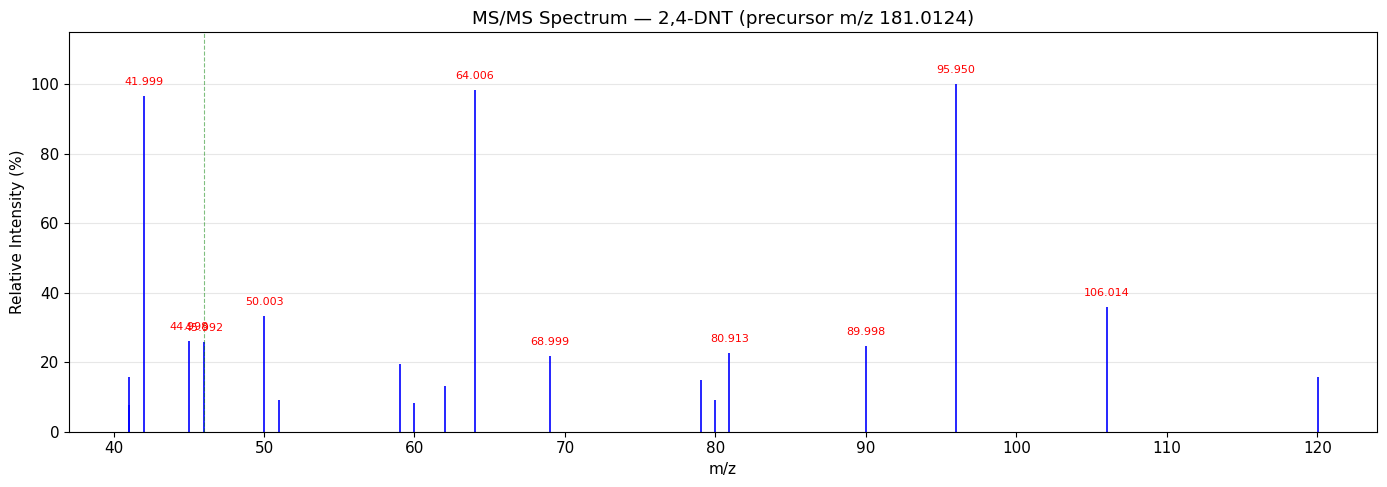

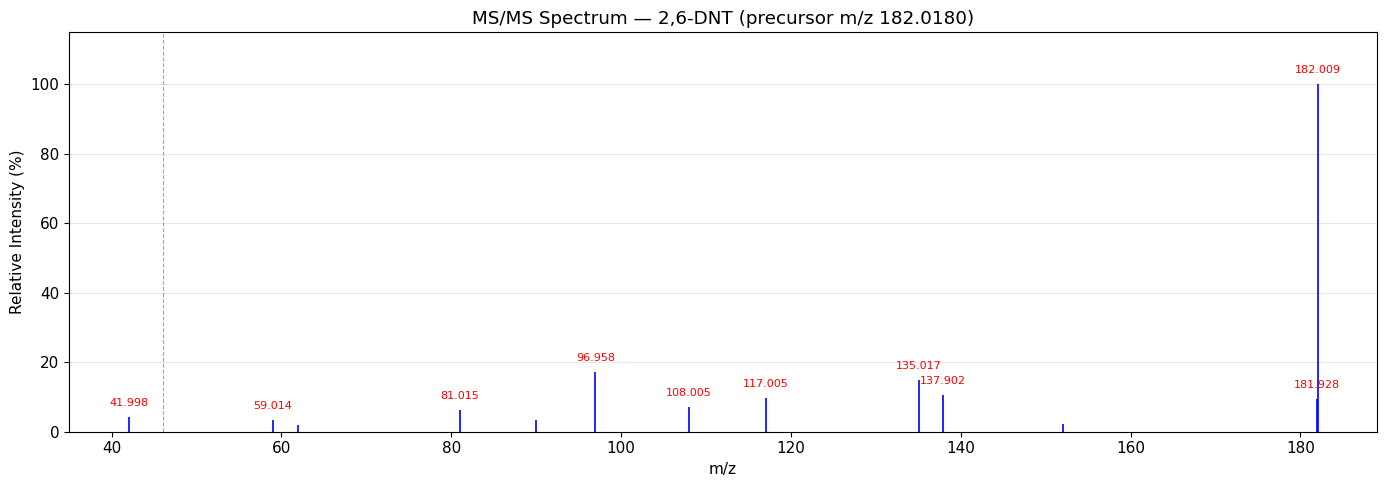

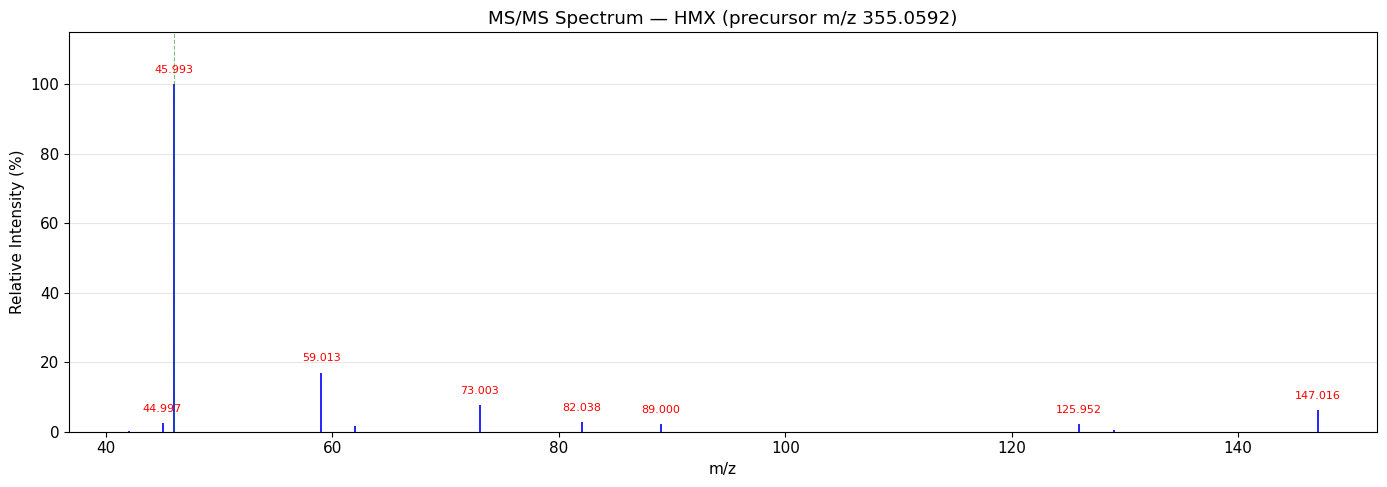

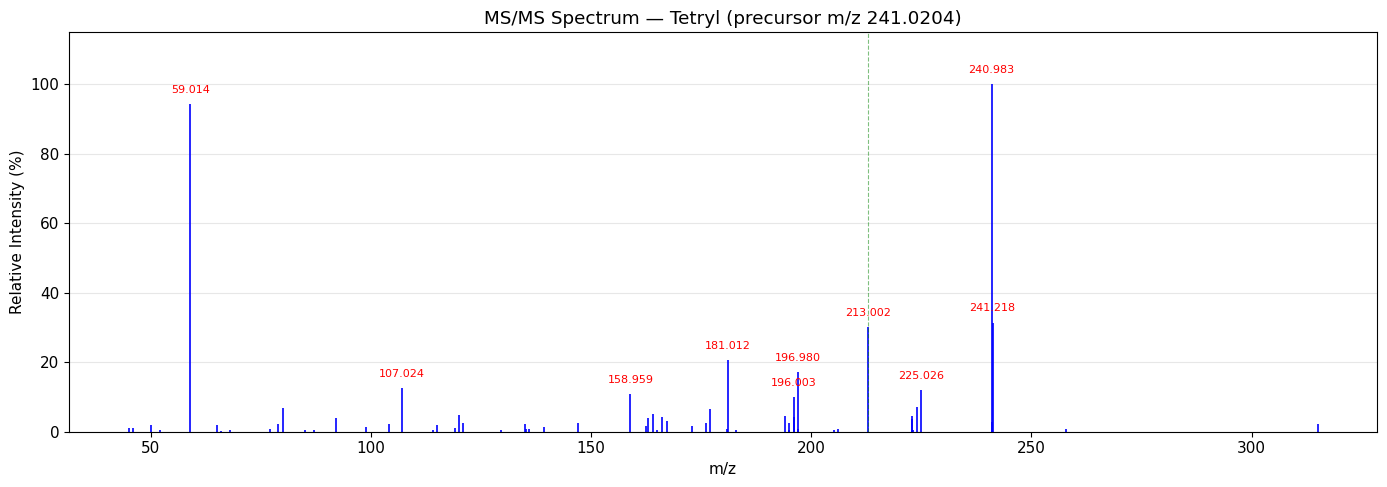

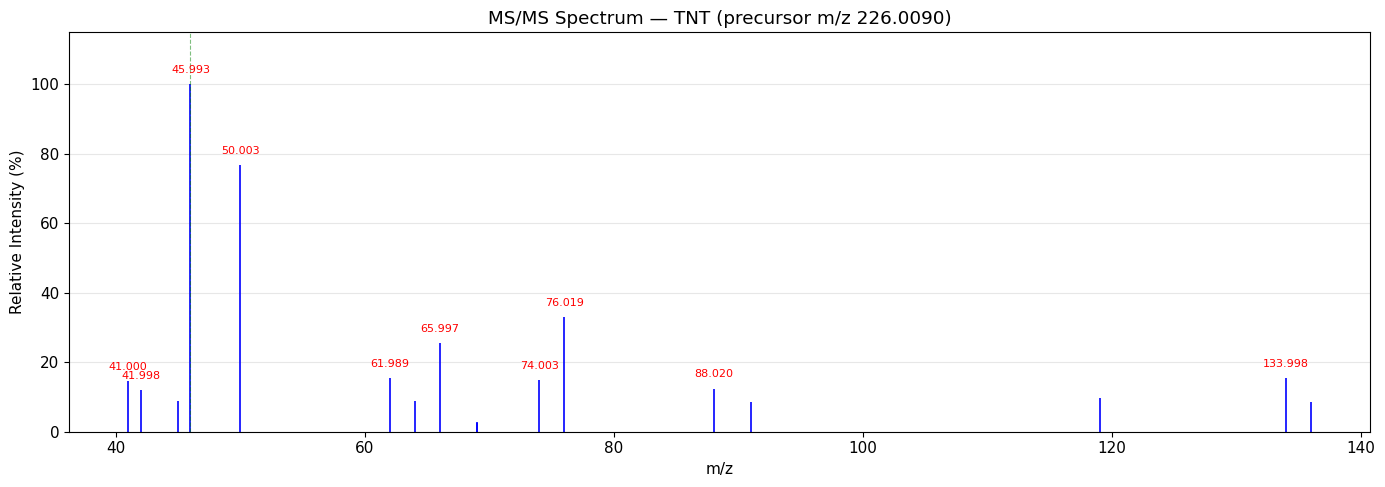

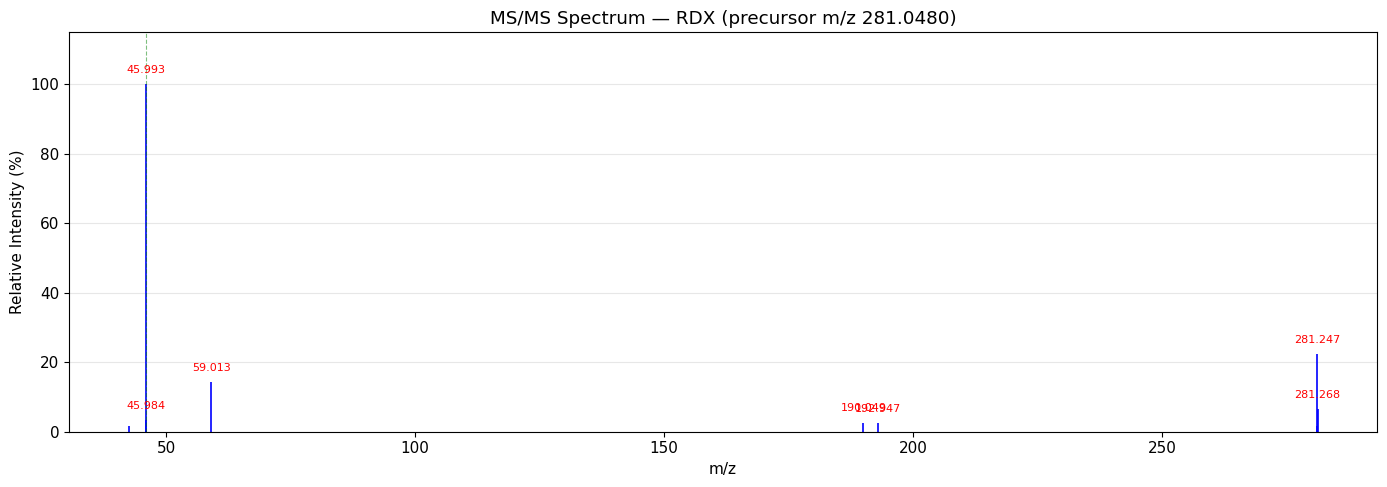

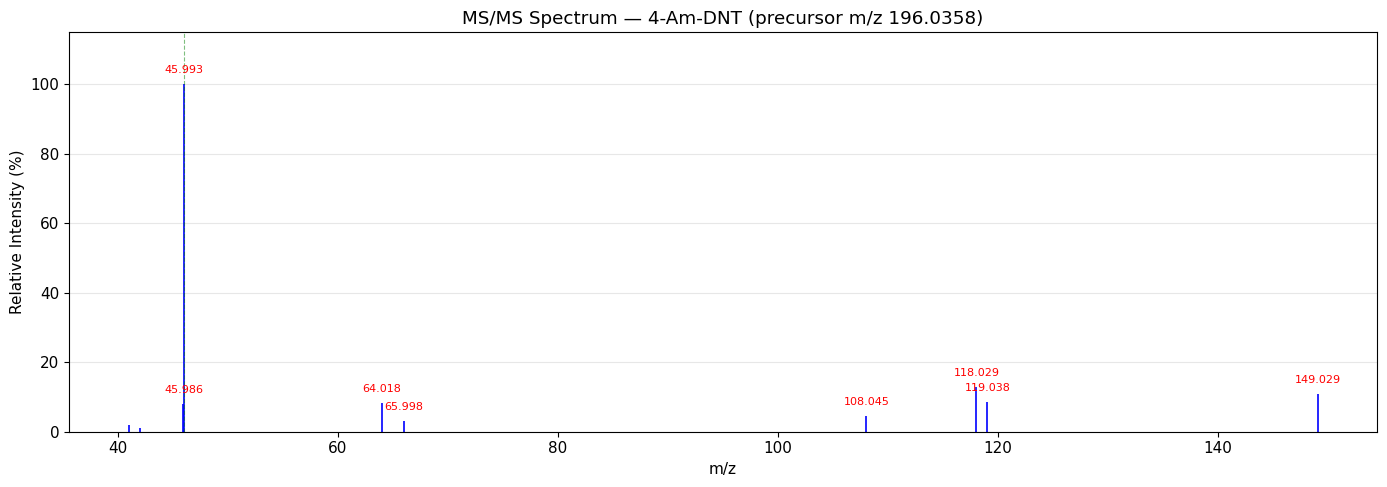

In [5]:
def plot_msms_spectrum(name, data, top_n=10):
    """MS/MS 스펙트럼을 스틱(stick) 플롯으로 시각화"""
    mz, intensity = data['mz'], data['intensity']
    
    # 상대 강도 (base peak = 100%)
    if intensity.max() > 0:
        rel_int = intensity / intensity.max() * 100
    else:
        return
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # Stick plot
    ax.vlines(mz, 0, rel_int, colors='blue', linewidth=1.2)
    
    # 상위 N개 피크에 m/z 라벨
    top_indices = np.argsort(intensity)[-top_n:]
    for idx in top_indices:
        if rel_int[idx] > 2:  # 2% 이상만 라벨
            ax.annotate(f'{mz[idx]:.3f}', 
                       (mz[idx], rel_int[idx]),
                       textcoords='offset points', xytext=(0, 8),
                       fontsize=8, ha='center', color='red')
    
    # MRM transition product ions 표시
    for trans in data.get('transitions', []):
        q3 = trans['product_mz']
        ax.axvline(q3, color='green', linestyle='--', alpha=0.5, linewidth=0.8)
    
    ax.set_xlabel('m/z')
    ax.set_ylabel('Relative Intensity (%)')
    ax.set_title(f'MS/MS Spectrum — {name} (precursor m/z {data["precursor_mz"]:.4f})')
    ax.set_ylim(0, 115)
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# 모든 화합물의 MS/MS 스펙트럼 시각화
for name, data in msms_spectra.items():
    plot_msms_spectrum(name, data)

### 4-1. Fragment Matching이란?

**Fragment matching**은 실제 MS/MS 스펙트럼에서 검출된 피크가 엑셀에 정의된 **Q3 (product ion) m/z**와 일치하는지 확인하는 과정입니다.

- Q3 매칭이 성공하면: 해당 화합물이 실제로 존재한다는 **강력한 증거**입니다
- Q3 매칭이 실패하면: 해당 m/z의 피크가 다른 화합물이거나 간섭일 가능성이 있습니다
- **tolerance_da**: fragment 매칭 허용 오차 (Da 단위, 보통 0.05 Da)

Fragment matching은 XIC만으로는 달성할 수 없는 **확실한 동정(identification)**을 제공합니다.

In [6]:
def match_fragments(msms_data, transitions, tolerance_da=0.05):
    """이론적 fragment (Q3)와 실측 MS/MS 스펙트럼 매칭"""
    mz = msms_data['mz']
    intensity = msms_data['intensity']
    rel_int = intensity / intensity.max() * 100 if intensity.max() > 0 else intensity
    
    results = []
    for trans in transitions:
        q3_target = trans['product_mz']
        # tolerance 내 가장 가까운 피크 찾기
        diffs = np.abs(mz - q3_target)
        min_idx = np.argmin(diffs)
        
        if diffs[min_idx] <= tolerance_da:
            error_mda = (mz[min_idx] - q3_target) * 1000
            results.append({
                'target_q3': q3_target,
                'found_mz': mz[min_idx],
                'error_mDa': error_mda,
                'intensity': intensity[min_idx],
                'rel_int_%': rel_int[min_idx],
                'matched': True
            })
        else:
            results.append({
                'target_q3': q3_target,
                'found_mz': None,
                'error_mDa': None,
                'intensity': 0,
                'rel_int_%': 0,
                'matched': False
            })
    return results

# Fragment 매칭 수행
print(f'{"Compound":12s} {"Q3 target":>10s} {"Found m/z":>10s} {"Error(mDa)":>10s} {"Rel.Int%":>8s} {"Match":>6s}')
print('-' * 60)
for name, data in msms_spectra.items():
    matches = match_fragments(data, data['transitions'])
    for m in matches:
        found_str = f'{m["found_mz"]:.3f}' if m['matched'] else '—'
        err_str = f'{m["error_mDa"]:.1f}' if m['matched'] else '—'
        rel_str = f'{m["rel_int_%"]:.1f}' if m['matched'] else '0.0'
        match_sym = '✓' if m['matched'] else '✗'
        print(f'{name:12s} {m["target_q3"]:10.3f} {found_str:>10s} {err_str:>10s} {rel_str:>8s} {match_sym:>6s}')

Compound      Q3 target  Found m/z Error(mDa) Rel.Int%  Match
------------------------------------------------------------
2,4-DNT          45.993     45.992       -1.0     25.8    YES
2,6-DNT          45.993          —          —      0.0     NO
HMX              45.993     45.993        0.1    100.0    YES
Tetryl          213.001    213.002        1.0     30.2    YES
TNT              45.993     45.993        0.2    100.0    YES
RDX              45.993     45.993       -0.2    100.0    YES
4-Am-DNT         45.993     45.993        0.0    100.0    YES


---

⬅️ **Prev:** [XIC Extraction](03%20XIC%20Extraction.ipynb) | **Next:** [Fragmentation Prediction](05%20Fragmentation%20Prediction.ipynb) ➡️